# Chapter 40 — Build a Multi-Sample Division Training Dataset

Chapter 39 showed that one sample does not contain enough reliable cell divisions to train a useful classifier.

This chapter builds the missing data-engineering layer:

```text
Many labeled training samples
        ↓
Chapter 37 refined tracks
        ↓
Chapter 38 division candidates
        ↓
Endpoint-level GT matching
        ↓
Pooled division training table
        ↓
Multi-sample LightGBM classifier
```

## Main outputs

```text
chapter40_pooled_division_training.csv
chapter40_sample_summary.csv
chapter40_label_audit.csv
chapter40_division_model.joblib
chapter40_feature_columns.json
chapter40_cv_predictions.csv
chapter40_cv_metrics.csv
chapter40_feature_importance.csv
chapter40_selected_divisions.csv
chapter40_outputs.zip
```


In [1]:
!pip install -q zarr lightgbm joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 79.0 MB/s eta 0:00:00


In [2]:
from __future__ import annotations

from dataclasses import dataclass
from itertools import combinations
from pathlib import Path
import json
import shutil
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from IPython.display import display

warnings.filterwarnings("ignore")


## Step 1 — Configuration

Add one entry for every sample whose Chapter 37 and Chapter 38 outputs you attached.


In [3]:
from dataclasses import dataclass
import pandas as pd
from IPython.display import display

@dataclass(frozen=True)
class TrainingConfig:
    node_match_radius: float = 6.0
    minimum_positive_examples: int = 5
    minimum_negative_examples: int = 25
    minimum_samples_for_group_cv: int = 3
    maximum_cv_splits: int = 5
    default_probability_threshold: float = 0.50
    minimum_precision_for_threshold: float = 0.20
    random_state: int = 42


CONFIG = TrainingConfig()

# All Chapter 37, 38, and 39 outputs are stored here
DATA_DIR = "/kaggle/input/datasets/emailchrismathews/data39"

SAMPLE_MANIFEST = [
    {
        "sample_id": "44b6_12dfb391",
        "chapter37_dir": DATA_DIR,
        "chapter38_dir": DATA_DIR,
    },
]

print(CONFIG)
display(pd.DataFrame(SAMPLE_MANIFEST))

TrainingConfig(node_match_radius=6.0, minimum_positive_examples=5, minimum_negative_examples=25, minimum_samples_for_group_cv=3, maximum_cv_splits=5, default_probability_threshold=0.5, minimum_precision_for_threshold=0.2, random_state=42)


,sample_id,chapter37_dir,chapter38_dir
0,44b6_12dfb391,/kaggle/input/datasets/emailchrismathews/data39,/kaggle/input/datasets/emailchrismathews/data39


## Step 2 — File helpers

In [4]:
from pathlib import Path

DATA_DIR = Path(
    "/kaggle/input/datasets/emailchrismathews/data39"
)

print("Checking folder:")
print(DATA_DIR)
print()

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Folder does not exist: {DATA_DIR}"
    )

print("Files found:")
files = sorted(DATA_DIR.iterdir())

for file in files:
    print(file.name)

print()
print("Total files:", len(files))

Checking folder:
/kaggle/input/datasets/emailchrismathews/data39

Files found:
chapter37_before_after_comparison.csv
chapter37_evaluated_links.csv
chapter37_gap_closing_links.csv
chapter37_gt_node_matches.csv
chapter37_link_summary.csv
chapter37_output_validation(1).csv
chapter37_output_validation.csv
chapter37_refined_track_edges.csv
chapter37_refined_track_nodes.csv
chapter37_refined_track_summary.csv
chapter38_division_candidates.csv
chapter38_division_evaluation.csv
chapter38_division_evaluation_summary.csv
chapter38_gt_node_matches.csv
chapter38_lineage_edges.csv
chapter38_lineage_nodes.csv
chapter38_lineage_summary.csv
chapter38_lineage_validation.csv
chapter38_parent_daughter_pairs.csv
chapter38_selected_divisions.csv
chapter38_track_to_gt_mapping.csv
chapter39_cv_metrics.csv
chapter39_cv_predictions.csv
chapter39_division_candidate_predictions.csv
chapter39_feature_columns.json
chapter39_feature_importance.csv
chapter39_final_metrics.csv
chapter39_label_audit.csv
chapter39_labe

In [5]:
from pathlib import Path
import pandas as pd
from IPython.display import display

DATA_DIR = Path(
    "/kaggle/input/datasets/emailchrismathews/data39"
)

track_nodes_path = (
    DATA_DIR
    / "chapter37_refined_track_nodes.csv"
)

division_candidates_path = (
    DATA_DIR
    / "chapter38_division_candidates.csv"
)

# Verify required files
required_paths = {
    "Chapter 37 refined track nodes": track_nodes_path,
    "Chapter 38 division candidates": division_candidates_path,
}

for name, path in required_paths.items():
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {name}: {path}"
        )

    print(f"Found {name}:")
    print(path)
    print()

# Load files
track_nodes_test_df = pd.read_csv(
    track_nodes_path
)

division_candidates_test_df = pd.read_csv(
    division_candidates_path
)

print(
    "Refined track nodes:",
    len(track_nodes_test_df),
)

print(
    "Division candidates:",
    len(division_candidates_test_df),
)

print(
    "Unique tracks:",
    track_nodes_test_df[
        "track_id"
    ].nunique(),
)

print()
print("Track-node preview:")
display(track_nodes_test_df.head())

print("Division-candidate preview:")
display(division_candidates_test_df.head())

Found Chapter 37 refined track nodes:
/kaggle/input/datasets/emailchrismathews/data39/chapter37_refined_track_nodes.csv

Found Chapter 38 division candidates:
/kaggle/input/datasets/emailchrismathews/data39/chapter38_division_candidates.csv

Refined track nodes: 4642
Division candidates: 93
Unique tracks: 591

Track-node preview:


,track_id,detection_id,t,z,y,x,z_physical,y_physical,x_physical,rank_position,pred_dist,original_track_id
0,0,chapter34_t0_0,0,41.0,130.0,131.0,66.625,52.81250,53.21875,1,7.354238,0
1,0,chapter34_t1_66,1,40.0,127.0,127.0,65.000,51.59375,51.59375,67,17.145113,0
2,0,chapter34_t5_121,5,36.0,80.0,82.0,58.500,32.50000,33.31250,122,17.788210,0
3,0,chapter34_t6_108,6,35.0,78.0,72.0,56.875,31.68750,29.25000,109,17.851830,0
4,1,chapter34_t0_1,0,24.0,123.0,85.0,39.000,49.96875,34.53125,2,7.437489,1


Division-candidate preview:


,parent_track_id,daughter_track_id_a,daughter_track_id_b,parent_end_t,daughter_start_t_a,daughter_start_t_b,frame_gap_a,frame_gap_b,distance_a,distance_b,...,daughter_mean_rank_b,parent_mean_pred_dist,daughter_mean_pred_dist_a,daughter_mean_pred_dist_b,distance_score,separation_score,balance_score,parent_quality_score,daughter_quality_score,division_score
0,83,155,156,14,15,15,1,1,9.911194,8.797476,...,58.882353,14.544073,13.405217,15.525601,0.740157,0.292533,0.679109,0.401419,0.552195,0.581799
1,349,389,390,61,62,62,1,1,11.440104,9.272829,...,43.400000,15.386548,16.003807,15.685215,0.712320,0.725038,0.555277,0.333126,0.312078,0.565904
2,108,181,185,17,20,20,3,3,27.948702,25.654936,...,80.666667,15.214449,15.726143,16.393109,0.255505,0.839483,0.958965,0.415234,0.511296,0.546122
3,108,185,188,17,20,20,3,3,25.654936,29.880785,...,77.791667,15.214449,16.393109,16.050463,0.228671,0.960825,0.804288,0.415234,0.555268,0.530591
4,208,318,365,56,58,57,2,1,17.525345,11.261994,...,96.000000,16.674182,16.271588,15.681017,0.600176,0.990664,0.521306,0.247673,0.151152,0.522746


In [6]:
from pathlib import Path

def require_file(folder, filename):
    path = Path(folder) / filename

    if not path.exists():
        raise FileNotFoundError(
            f"Missing required file: {path}"
        )

    return path


def find_geff_path(sample_id):
    expected = Path(
        "/kaggle/input/competitions/"
        "biohub-cell-tracking-during-development/train"
    ) / f"{sample_id}.geff"

    if expected.exists():
        return expected

    matches = list(
        Path("/kaggle/input").rglob(
            f"{sample_id}.geff"
        )
    )

    if matches:
        return sorted(
            matches,
            key=lambda path: len(str(path)),
        )[0]

    raise FileNotFoundError(
        f"Could not find GEFF file for {sample_id}."
    )


print("File helper functions loaded successfully.")
print("Run the next cell.")

File helper functions loaded successfully.
Run the next cell.


## Step 3 — Load GT nodes and true divisions

In [7]:
def load_gt_nodes_and_divisions(sample_id):
    geff_path = find_geff_path(sample_id)
    geff = zarr.open(geff_path, mode="r")

    gt_nodes = pd.DataFrame({
        "gt_node_id": geff["nodes/ids"][:],
        "t": geff["nodes/props/t/values"][:],
        "z": geff["nodes/props/z/values"][:],
        "y": geff["nodes/props/y/values"][:],
        "x": geff["nodes/props/x/values"][:],
    })

    edge_ids = np.asarray(geff["edges/ids"][:])

    gt_edges = pd.DataFrame({
        "gt_source": edge_ids[:, 0],
        "gt_target": edge_ids[:, 1],
    })

    division_rows = []

    for parent, group in gt_edges.groupby("gt_source", sort=True):
        daughters = sorted(group["gt_target"].unique())

        if len(daughters) < 2:
            continue

        for daughter_a, daughter_b in combinations(daughters, 2):
            division_rows.append({
                "gt_parent": parent,
                "gt_daughter_a": daughter_a,
                "gt_daughter_b": daughter_b,
            })

    return geff_path, gt_nodes, gt_edges, pd.DataFrame(division_rows)


## Step 4 — Build refined-track endpoints

In [8]:
def build_track_endpoints(track_nodes):
    required = {"track_id", "detection_id", "t", "z", "y", "x"}
    missing = required - set(track_nodes.columns)

    if missing:
        raise ValueError(f"Track nodes are missing columns: {sorted(missing)}")

    rows = []

    for track_id, group in track_nodes.groupby("track_id", sort=True):
        group = group.sort_values("t").reset_index(drop=True)
        start = group.iloc[0]
        end = group.iloc[-1]

        rows.append({
            "track_id": int(track_id),
            "start_detection_id": start["detection_id"],
            "end_detection_id": end["detection_id"],
            "start_t": int(start["t"]),
            "end_t": int(end["t"]),
            "start_z": float(start["z"]),
            "start_y": float(start["y"]),
            "start_x": float(start["x"]),
            "end_z": float(end["z"]),
            "end_y": float(end["y"]),
            "end_x": float(end["x"]),
            "num_detections": len(group),
        })

    return pd.DataFrame(rows)


## Step 5 — Match endpoints directly to GT nodes

In [9]:
def match_endpoint_table_to_gt(endpoint_table, gt_nodes, endpoint_kind, radius):
    if endpoint_kind not in {"start", "end"}:
        raise ValueError("endpoint_kind must be 'start' or 'end'.")

    time_column = f"{endpoint_kind}_t"
    coordinate_columns = [
        f"{endpoint_kind}_z",
        f"{endpoint_kind}_y",
        f"{endpoint_kind}_x",
    ]

    rows = []

    for timepoint in sorted(endpoint_table[time_column].unique()):
        pred_t = endpoint_table[
            endpoint_table[time_column] == timepoint
        ].reset_index(drop=True)

        gt_t = gt_nodes[
            gt_nodes["t"] == timepoint
        ].reset_index(drop=True)

        if pred_t.empty or gt_t.empty:
            continue

        distances = cdist(
            pred_t[coordinate_columns].to_numpy(dtype=np.float32),
            gt_t[["z", "y", "x"]].to_numpy(dtype=np.float32),
        )

        safe_distances = np.where(distances <= radius, distances, 1e9)
        pred_indices, gt_indices = linear_sum_assignment(safe_distances)

        for pred_index, gt_index in zip(pred_indices, gt_indices):
            distance = float(distances[pred_index, gt_index])

            if distance > radius:
                continue

            rows.append({
                "track_id": int(pred_t.iloc[pred_index]["track_id"]),
                f"{endpoint_kind}_gt_node_id": gt_t.iloc[gt_index]["gt_node_id"],
                f"{endpoint_kind}_match_distance": distance,
            })

    return pd.DataFrame(rows)


## Step 6 — Label one sample with endpoint-level GT matching

In [10]:
def label_sample_candidates(
    sample_id,
    chapter37_dir,
    chapter38_dir,
    config=CONFIG,
):
    track_nodes_path = require_file(
        chapter37_dir,
        "chapter37_refined_track_nodes.csv",
    )

    candidates_path = require_file(
        chapter38_dir,
        "chapter38_division_candidates.csv",
    )

    track_nodes = pd.read_csv(track_nodes_path)
    candidates = pd.read_csv(candidates_path)

    geff_path, gt_nodes, gt_edges, gt_divisions = (
        load_gt_nodes_and_divisions(sample_id)
    )

    endpoints = build_track_endpoints(track_nodes)

    start_matches = match_endpoint_table_to_gt(
        endpoints,
        gt_nodes,
        endpoint_kind="start",
        radius=config.node_match_radius,
    )

    end_matches = match_endpoint_table_to_gt(
        endpoints,
        gt_nodes,
        endpoint_kind="end",
        radius=config.node_match_radius,
    )

    start_map = (
        start_matches.set_index("track_id")
        if not start_matches.empty
        else pd.DataFrame()
    )

    end_map = (
        end_matches.set_index("track_id")
        if not end_matches.empty
        else pd.DataFrame()
    )

    true_divisions = {
        (
            row.gt_parent,
            frozenset([row.gt_daughter_a, row.gt_daughter_b]),
        )
        for row in gt_divisions.itertuples(index=False)
    }

    rows = []

    for row in candidates.itertuples(index=False):
        parent_track = int(row.parent_track_id)
        daughter_a_track = int(row.daughter_track_id_a)
        daughter_b_track = int(row.daughter_track_id_b)

        parent_gt = None
        daughter_a_gt = None
        daughter_b_gt = None

        parent_distance = np.nan
        daughter_a_distance = np.nan
        daughter_b_distance = np.nan

        if not end_matches.empty and parent_track in end_map.index:
            parent_gt = end_map.loc[parent_track, "end_gt_node_id"]
            parent_distance = float(
                end_map.loc[parent_track, "end_match_distance"]
            )

        if not start_matches.empty and daughter_a_track in start_map.index:
            daughter_a_gt = start_map.loc[
                daughter_a_track,
                "start_gt_node_id",
            ]
            daughter_a_distance = float(
                start_map.loc[
                    daughter_a_track,
                    "start_match_distance",
                ]
            )

        if not start_matches.empty and daughter_b_track in start_map.index:
            daughter_b_gt = start_map.loc[
                daughter_b_track,
                "start_gt_node_id",
            ]
            daughter_b_distance = float(
                start_map.loc[
                    daughter_b_track,
                    "start_match_distance",
                ]
            )

        all_matched = (
            parent_gt is not None
            and daughter_a_gt is not None
            and daughter_b_gt is not None
        )

        if all_matched:
            positive = (
                parent_gt,
                frozenset([daughter_a_gt, daughter_b_gt]),
            ) in true_divisions

            label = int(positive)
            status = "positive" if positive else "reliable_negative"
        else:
            label = np.nan
            status = "unlabeled_endpoint_missing"

        candidate = row._asdict()

        candidate.update({
            "sample_id": sample_id,
            "gt_parent_endpoint": parent_gt,
            "gt_daughter_a_endpoint": daughter_a_gt,
            "gt_daughter_b_endpoint": daughter_b_gt,
            "parent_endpoint_match_distance": parent_distance,
            "daughter_a_endpoint_match_distance": daughter_a_distance,
            "daughter_b_endpoint_match_distance": daughter_b_distance,
            "all_endpoints_matched": all_matched,
            "division_label": label,
            "label_status": status,
        })

        rows.append(candidate)

    labeled = pd.DataFrame(rows)

    summary = {
        "sample_id": sample_id,
        "geff_path": str(geff_path),
        "track_nodes": len(track_nodes),
        "tracks": track_nodes["track_id"].nunique(),
        "division_candidates": len(candidates),
        "gt_divisions": len(gt_divisions),
        "matched_start_endpoints": len(start_matches),
        "matched_end_endpoints": len(end_matches),
        "labeled_candidates": int(labeled["division_label"].notna().sum()),
        "positive_candidates": int((labeled["division_label"] == 1).sum()),
        "negative_candidates": int((labeled["division_label"] == 0).sum()),
        "unlabeled_candidates": int(labeled["division_label"].isna().sum()),
    }

    return (
        labeled,
        summary,
        endpoints,
        start_matches,
        end_matches,
        gt_divisions,
    )


## Step 7 — Process every sample in the manifest

In [11]:
all_labeled_tables = []
sample_summary_rows = []
endpoint_tables = []
endpoint_match_tables = []
gt_division_tables = []

for item in SAMPLE_MANIFEST:
    sample_id = item["sample_id"]

    print()
    print("=" * 70)
    print("Processing:", sample_id)
    print("=" * 70)

    try:
        (
            labeled_sample,
            sample_summary,
            endpoints,
            start_matches,
            end_matches,
            gt_divisions,
        ) = label_sample_candidates(
            sample_id=sample_id,
            chapter37_dir=item["chapter37_dir"],
            chapter38_dir=item["chapter38_dir"],
            config=CONFIG,
        )

        all_labeled_tables.append(labeled_sample)
        sample_summary_rows.append(sample_summary)

        endpoints = endpoints.copy()
        endpoints["sample_id"] = sample_id
        endpoint_tables.append(endpoints)

        if not start_matches.empty:
            start_matches = start_matches.copy()
            start_matches["sample_id"] = sample_id
            start_matches["endpoint_kind"] = "start"
            endpoint_match_tables.append(start_matches)

        if not end_matches.empty:
            end_matches = end_matches.copy()
            end_matches["sample_id"] = sample_id
            end_matches["endpoint_kind"] = "end"
            endpoint_match_tables.append(end_matches)

        if not gt_divisions.empty:
            gt_divisions = gt_divisions.copy()
            gt_divisions["sample_id"] = sample_id
            gt_division_tables.append(gt_divisions)

        print(labeled_sample["label_status"].value_counts(dropna=False))

    except Exception as error:
        print(f"FAILED {sample_id}: {error}")

if not all_labeled_tables:
    raise RuntimeError("No sample was processed successfully.")

pooled_candidates_df = pd.concat(
    all_labeled_tables,
    ignore_index=True,
)

sample_summary_df = pd.DataFrame(sample_summary_rows)

all_endpoints_df = pd.concat(
    endpoint_tables,
    ignore_index=True,
)

all_endpoint_matches_df = (
    pd.concat(endpoint_match_tables, ignore_index=True)
    if endpoint_match_tables
    else pd.DataFrame()
)

all_gt_divisions_df = (
    pd.concat(gt_division_tables, ignore_index=True)
    if gt_division_tables
    else pd.DataFrame()
)

print("Pooled candidates:", len(pooled_candidates_df))
display(sample_summary_df)



Processing: 44b6_12dfb391
label_status
unlabeled_endpoint_missing    93
Name: count, dtype: int64
Pooled candidates: 93


,sample_id,geff_path,track_nodes,tracks,division_candidates,gt_divisions,matched_start_endpoints,matched_end_endpoints,labeled_candidates,positive_candidates,negative_candidates,unlabeled_candidates
0,44b6_12dfb391,/kaggle/input/competitions/biohub-cell-trackin...,4642,591,93,1,53,38,0,0,0,93


## Step 8 — Audit pooled labels

In [12]:
label_audit_df = pd.DataFrame({
    "metric": [
        "samples_processed",
        "total_candidates",
        "labeled_candidates",
        "unlabeled_candidates",
        "positive_candidates",
        "negative_candidates",
        "positive_fraction_labeled",
    ],
    "value": [
        pooled_candidates_df["sample_id"].nunique(),
        len(pooled_candidates_df),
        pooled_candidates_df["division_label"].notna().sum(),
        pooled_candidates_df["division_label"].isna().sum(),
        (pooled_candidates_df["division_label"] == 1).sum(),
        (pooled_candidates_df["division_label"] == 0).sum(),
        (
            (pooled_candidates_df["division_label"] == 1).sum()
            / max(
                pooled_candidates_df["division_label"].notna().sum(),
                1,
            )
        ),
    ],
})

display(label_audit_df)


,metric,value
0,samples_processed,1.0
1,total_candidates,93.0
2,labeled_candidates,0.0
3,unlabeled_candidates,93.0
4,positive_candidates,0.0
5,negative_candidates,0.0
6,positive_fraction_labeled,0.0


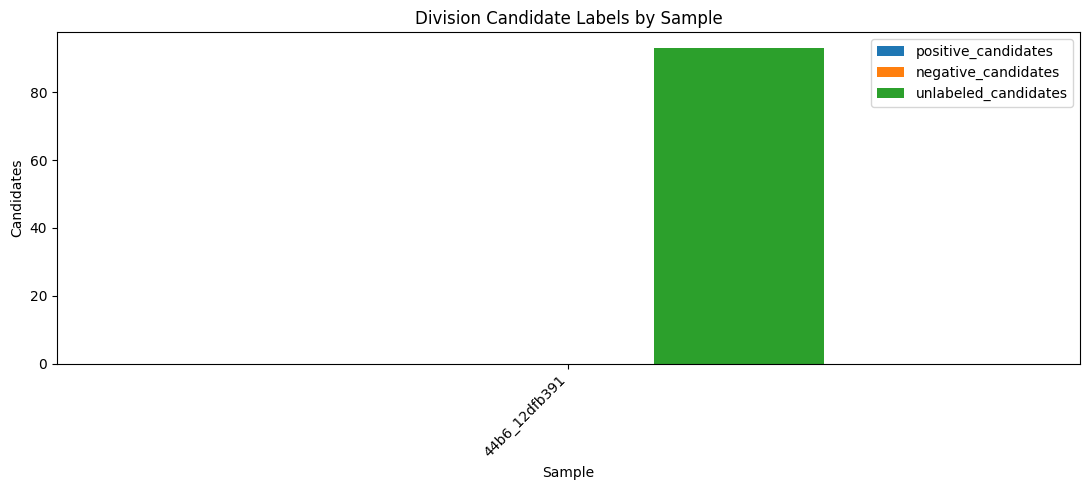

In [13]:
plot_table = sample_summary_df.set_index("sample_id")[
    [
        "positive_candidates",
        "negative_candidates",
        "unlabeled_candidates",
    ]
]

plot_table.plot(kind="bar", figsize=(11, 5))
plt.title("Division Candidate Labels by Sample")
plt.xlabel("Sample")
plt.ylabel("Candidates")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Step 9 — Define model features

In [14]:
FEATURE_COLUMNS = [
    "frame_gap_a",
    "frame_gap_b",
    "distance_a",
    "distance_b",
    "mean_distance",
    "distance_balance",
    "daughter_separation",
    "daughter_length_balance",
    "parent_num_detections",
    "daughter_num_detections_a",
    "daughter_num_detections_b",
    "parent_mean_rank",
    "daughter_mean_rank_a",
    "daughter_mean_rank_b",
    "parent_mean_pred_dist",
    "daughter_mean_pred_dist_a",
    "daughter_mean_pred_dist_b",
    "distance_score",
    "separation_score",
    "balance_score",
    "parent_quality_score",
    "daughter_quality_score",
    "parent_endpoint_match_distance",
    "daughter_a_endpoint_match_distance",
    "daughter_b_endpoint_match_distance",
]

missing = [
    column
    for column in FEATURE_COLUMNS
    if column not in pooled_candidates_df.columns
]

if missing:
    raise ValueError(f"Missing model features: {missing}")

display(pooled_candidates_df[FEATURE_COLUMNS].describe().T)


,count,mean,std,min,25%,50%,75%,max
frame_gap_a,93.0,2.655914,0.541628,1.000000,2.000000,3.000000,3.000000,3.000000
frame_gap_b,93.0,2.720430,0.518476,1.000000,3.000000,3.000000,3.000000,3.000000
distance_a,93.0,26.998642,6.074328,9.422898,21.781216,27.948702,32.349850,35.952553
distance_b,93.0,27.796343,6.157800,8.797476,24.344166,29.264103,32.349850,35.881329
mean_distance,93.0,27.397493,5.856575,9.354335,24.223204,28.661045,31.855729,35.875496
distance_balance,93.0,0.904354,0.084487,0.561896,0.877423,0.929414,0.962058,0.999642
daughter_separation,93.0,7.251126,4.667010,1.284675,3.067120,5.915089,10.444655,17.586449
daughter_length_balance,93.0,0.539585,0.266128,0.071429,0.300000,0.500000,0.750000,1.000000
parent_num_detections,93.0,8.236559,5.842866,3.000000,3.000000,8.000000,8.000000,30.000000
daughter_num_detections_a,93.0,9.720430,7.494006,2.000000,4.000000,7.000000,18.000000,42.000000


## Step 10 — Determine whether model training is possible

In [15]:
training_df = pooled_candidates_df[
    pooled_candidates_df["division_label"].notna()
].copy()

positive_count = int((training_df["division_label"] == 1).sum())
negative_count = int((training_df["division_label"] == 0).sum())
sample_count = training_df["sample_id"].nunique()

can_train = (
    positive_count >= CONFIG.minimum_positive_examples
    and negative_count >= CONFIG.minimum_negative_examples
)

can_group_cv = (
    can_train
    and sample_count >= CONFIG.minimum_samples_for_group_cv
)

print("Labeled rows:", len(training_df))
print("Positive rows:", positive_count)
print("Negative rows:", negative_count)
print("Labeled samples:", sample_count)
print("Can train:", can_train)
print("Can run sample-grouped CV:", can_group_cv)


Labeled rows: 0
Positive rows: 0
Negative rows: 0
Labeled samples: 0
Can train: False
Can run sample-grouped CV: False


## Step 11 — Build LightGBM with an ExtraTrees fallback

In [16]:
def make_model(random_state):
    try:
        from lightgbm import LGBMClassifier

        classifier = LGBMClassifier(
            objective="binary",
            n_estimators=500,
            learning_rate=0.025,
            num_leaves=15,
            min_child_samples=10,
            subsample=0.85,
            colsample_bytree=0.85,
            class_weight="balanced",
            random_state=random_state,
            verbosity=-1,
        )
        model_name = "LightGBM"

    except Exception:
        classifier = ExtraTreesClassifier(
            n_estimators=500,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1,
        )
        model_name = "ExtraTrees"

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", classifier),
    ])

    return model, model_name


base_model, model_name = make_model(CONFIG.random_state)
print("Model:", model_name)


Model: LightGBM


## Step 12 — Sample-grouped cross-validation

In [17]:
def binary_metrics(y_true, probabilities, threshold):
    y_true = np.asarray(y_true).astype(int)
    predictions = (np.asarray(probabilities) >= threshold).astype(int)

    result = {
        "average_precision": np.nan,
        "roc_auc": np.nan,
        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0,
        ),
    }

    if len(np.unique(y_true)) == 2:
        result["average_precision"] = average_precision_score(
            y_true,
            probabilities,
        )
        result["roc_auc"] = roc_auc_score(
            y_true,
            probabilities,
        )

    return result


def run_grouped_cv(training, model):
    groups = training["sample_id"].astype(str)
    n_splits = min(CONFIG.maximum_cv_splits, groups.nunique())

    splitter = GroupKFold(n_splits=n_splits)

    X = training[FEATURE_COLUMNS]
    y = training["division_label"].astype(int)

    prediction_rows = []
    metric_rows = []

    for fold, (train_index, valid_index) in enumerate(
        splitter.split(X, y, groups),
        start=1,
    ):
        y_train = y.iloc[train_index]
        y_valid = y.iloc[valid_index]

        if y_train.nunique() < 2:
            print(f"Skipping fold {fold}: one-class training fold.")
            continue

        fold_model = clone(model)
        fold_model.fit(X.iloc[train_index], y_train)

        probabilities = fold_model.predict_proba(
            X.iloc[valid_index]
        )[:, 1]

        metrics = binary_metrics(y_valid, probabilities, 0.50)
        metrics["fold"] = fold
        metrics["train_rows"] = len(train_index)
        metrics["validation_rows"] = len(valid_index)
        metrics["validation_positives"] = int(y_valid.sum())
        metrics["validation_samples"] = ",".join(
            sorted(groups.iloc[valid_index].unique())
        )
        metric_rows.append(metrics)

        fold_predictions = training.iloc[valid_index][[
            "sample_id",
            "parent_track_id",
            "daughter_track_id_a",
            "daughter_track_id_b",
            "division_label",
        ]].copy()

        fold_predictions["division_probability"] = probabilities
        fold_predictions["fold"] = fold
        prediction_rows.append(fold_predictions)

    if not prediction_rows:
        return pd.DataFrame(), pd.DataFrame()

    return (
        pd.concat(prediction_rows, ignore_index=True),
        pd.DataFrame(metric_rows),
    )


if can_group_cv:
    cv_predictions_df, cv_metrics_df = run_grouped_cv(
        training_df,
        base_model,
    )
else:
    cv_predictions_df = pd.DataFrame()
    cv_metrics_df = pd.DataFrame()

if cv_metrics_df.empty:
    print("Sample-grouped cross-validation was skipped.")
else:
    display(cv_metrics_df)
    display(cv_metrics_df.mean(numeric_only=True).to_frame("mean").T)


Sample-grouped cross-validation was skipped.


## Step 13 — Select a probability threshold

In [18]:
def choose_threshold(y_true, probabilities):
    if len(np.unique(y_true)) < 2:
        return CONFIG.default_probability_threshold, pd.DataFrame()

    precision, recall, thresholds = precision_recall_curve(
        y_true,
        probabilities,
    )

    rows = []

    for index, threshold in enumerate(thresholds):
        p = float(precision[index])
        r = float(recall[index])
        f1 = 2 * p * r / (p + r) if p + r > 0 else 0.0

        rows.append({
            "threshold": float(threshold),
            "precision": p,
            "recall": r,
            "f1": f1,
        })

    table = pd.DataFrame(rows)

    eligible = table[
        table["precision"] >= CONFIG.minimum_precision_for_threshold
    ]

    pool = eligible if not eligible.empty else table

    best = pool.sort_values(
        ["f1", "recall"],
        ascending=False,
    ).iloc[0]

    return float(best["threshold"]), table


if not cv_predictions_df.empty:
    selected_threshold, threshold_search_df = choose_threshold(
        cv_predictions_df["division_label"].astype(int),
        cv_predictions_df["division_probability"],
    )
else:
    selected_threshold = CONFIG.default_probability_threshold
    threshold_search_df = pd.DataFrame()

print("Selected threshold:", selected_threshold)


Selected threshold: 0.5


## Step 14 — Train the final pooled model or use a safe fallback

In [19]:
final_model = None

if can_train:
    final_model = clone(base_model)

    final_model.fit(
        training_df[FEATURE_COLUMNS],
        training_df["division_label"].astype(int),
    )

    pooled_candidates_df["division_probability"] = (
        final_model.predict_proba(
            pooled_candidates_df[FEATURE_COLUMNS]
        )[:, 1]
    )

    prediction_source = f"trained_{model_name.lower()}"

else:
    heuristic = pooled_candidates_df["division_score"].astype(float)

    if heuristic.max() > heuristic.min():
        pooled_candidates_df["division_probability"] = (
            (heuristic - heuristic.min())
            / (heuristic.max() - heuristic.min())
        )
    else:
        pooled_candidates_df["division_probability"] = 0.5

    prediction_source = "heuristic_fallback_insufficient_labels"

print("Prediction source:", prediction_source)

display(
    pooled_candidates_df.sort_values(
        "division_probability",
        ascending=False,
    )[[
        "sample_id",
        "parent_track_id",
        "daughter_track_id_a",
        "daughter_track_id_b",
        "division_probability",
        "division_label",
        "label_status",
    ]].head(30)
)


Prediction source: heuristic_fallback_insufficient_labels


,sample_id,parent_track_id,daughter_track_id_a,daughter_track_id_b,division_probability,division_label,label_status
0,44b6_12dfb391,83,155,156,1.000000,NaN,unlabeled_endpoint_missing
1,44b6_12dfb391,349,389,390,0.951906,NaN,unlabeled_endpoint_missing
2,44b6_12dfb391,108,181,185,0.892051,NaN,unlabeled_endpoint_missing
3,44b6_12dfb391,108,185,188,0.845061,NaN,unlabeled_endpoint_missing
4,44b6_12dfb391,208,318,365,0.821324,NaN,unlabeled_endpoint_missing
5,44b6_12dfb391,418,515,524,0.806039,NaN,unlabeled_endpoint_missing
6,44b6_12dfb391,66,165,166,0.787677,NaN,unlabeled_endpoint_missing
7,44b6_12dfb391,366,392,393,0.760885,NaN,unlabeled_endpoint_missing
8,44b6_12dfb391,69,181,185,0.726587,NaN,unlabeled_endpoint_missing
9,44b6_12dfb391,69,185,188,0.719491,NaN,unlabeled_endpoint_missing


## Step 15 — Feature importance

In [20]:
feature_importance_df = pd.DataFrame()

if final_model is not None:
    classifier = final_model.named_steps["classifier"]

    if hasattr(classifier, "feature_importances_"):
        feature_importance_df = (
            pd.DataFrame({
                "feature": FEATURE_COLUMNS,
                "importance": classifier.feature_importances_,
            })
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )

if feature_importance_df.empty:
    print("Feature importance unavailable because no model was trained.")
else:
    display(feature_importance_df)

    top = feature_importance_df.head(15)

    plt.figure(figsize=(10, 7))
    plt.barh(top["feature"][::-1], top["importance"][::-1])
    plt.title(f"{model_name} Division Feature Importance")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()


Feature importance unavailable because no model was trained.


## Step 16 — Select non-conflicting divisions per sample

In [21]:
def select_non_conflicting_divisions(candidates, threshold):
    selected_rows = []

    for sample_id, sample_table in candidates.groupby(
        "sample_id",
        sort=True,
    ):
        ordered = sample_table.sort_values(
            "division_probability",
            ascending=False,
        )

        used_parents = set()
        used_daughters = set()

        for row in ordered.itertuples(index=False):
            if row.division_probability < threshold:
                continue

            parent = int(row.parent_track_id)
            daughter_a = int(row.daughter_track_id_a)
            daughter_b = int(row.daughter_track_id_b)

            if parent in used_parents:
                continue

            if daughter_a in used_daughters or daughter_b in used_daughters:
                continue

            if daughter_a == daughter_b:
                continue

            if parent in {daughter_a, daughter_b}:
                continue

            selected_rows.append(row._asdict())
            used_parents.add(parent)
            used_daughters.update([daughter_a, daughter_b])

    return pd.DataFrame(selected_rows)


selected_divisions_df = select_non_conflicting_divisions(
    pooled_candidates_df,
    selected_threshold,
)

print("Selected divisions:", len(selected_divisions_df))

if not selected_divisions_df.empty:
    display(
        selected_divisions_df[[
            "sample_id",
            "parent_track_id",
            "daughter_track_id_a",
            "daughter_track_id_b",
            "division_probability",
            "division_label",
        ]].head(30)
    )


Selected divisions: 18


,sample_id,parent_track_id,daughter_track_id_a,daughter_track_id_b,division_probability,division_label
0,44b6_12dfb391,83,155,156,1.000000,NaN
1,44b6_12dfb391,349,389,390,0.951906,NaN
2,44b6_12dfb391,108,181,185,0.892051,NaN
3,44b6_12dfb391,208,318,365,0.821324,NaN
4,44b6_12dfb391,418,515,524,0.806039,NaN
5,44b6_12dfb391,66,165,166,0.787677,NaN
6,44b6_12dfb391,366,392,393,0.760885,NaN
7,44b6_12dfb391,329,370,399,0.660440,NaN
8,44b6_12dfb391,405,509,511,0.645655,NaN
9,44b6_12dfb391,96,183,184,0.640929,NaN


## Step 17 — Evaluate labeled predictions

In [22]:
evaluation_df = pooled_candidates_df[
    pooled_candidates_df["division_label"].notna()
].copy()

if (
    not evaluation_df.empty
    and evaluation_df["division_label"].nunique() == 2
):
    final_metrics = binary_metrics(
        evaluation_df["division_label"].astype(int),
        evaluation_df["division_probability"],
        selected_threshold,
    )

    final_metrics_df = pd.DataFrame([{
        **final_metrics,
        "threshold": selected_threshold,
        "prediction_source": prediction_source,
        "labeled_rows": len(evaluation_df),
        "positive_rows": int(evaluation_df["division_label"].sum()),
        "samples": evaluation_df["sample_id"].nunique(),
    }])

    predicted_labels = (
        evaluation_df["division_probability"] >= selected_threshold
    ).astype(int)

    confusion_df = pd.DataFrame(
        confusion_matrix(
            evaluation_df["division_label"].astype(int),
            predicted_labels,
            labels=[0, 1],
        ),
        index=["actual_negative", "actual_positive"],
        columns=["predicted_negative", "predicted_positive"],
    )

    display(final_metrics_df)
    display(confusion_df)

else:
    final_metrics_df = pd.DataFrame([{
        "average_precision": np.nan,
        "roc_auc": np.nan,
        "precision": np.nan,
        "recall": np.nan,
        "f1": np.nan,
        "threshold": selected_threshold,
        "prediction_source": prediction_source,
        "labeled_rows": len(evaluation_df),
        "positive_rows": int(
            (evaluation_df["division_label"] == 1).sum()
        ),
        "samples": evaluation_df["sample_id"].nunique(),
        "note": "Metrics require both positive and negative labels.",
    }])

    confusion_df = pd.DataFrame()
    display(final_metrics_df)


,average_precision,roc_auc,precision,recall,f1,threshold,prediction_source,labeled_rows,positive_rows,samples,note
0,NaN,NaN,NaN,NaN,NaN,0.5,heuristic_fallback_insufficient_labels,0,0,0,Metrics require both positive and negative lab...


## Step 18 — Validate outputs

In [23]:
validation_rows = [
    {
        "check": "sample_id_present",
        "passed": bool(pooled_candidates_df["sample_id"].notna().all()),
        "details": f"{pooled_candidates_df['sample_id'].nunique()} samples",
    },
    {
        "check": "feature_columns_present",
        "passed": bool(
            all(column in pooled_candidates_df.columns for column in FEATURE_COLUMNS)
        ),
        "details": f"{len(FEATURE_COLUMNS)} features",
    },
]

if selected_divisions_df.empty:
    validation_rows.append({
        "check": "selected_lineage_constraints",
        "passed": True,
        "details": "No candidates exceeded the threshold.",
    })
else:
    duplicate_parent = selected_divisions_df.duplicated(
        ["sample_id", "parent_track_id"]
    ).any()

    daughters = pd.concat([
        selected_divisions_df[
            ["sample_id", "daughter_track_id_a"]
        ].rename(columns={"daughter_track_id_a": "daughter_track_id"}),

        selected_divisions_df[
            ["sample_id", "daughter_track_id_b"]
        ].rename(columns={"daughter_track_id_b": "daughter_track_id"}),
    ], ignore_index=True)

    duplicate_daughter = daughters.duplicated(
        ["sample_id", "daughter_track_id"]
    ).any()

    validation_rows.append({
        "check": "selected_lineage_constraints",
        "passed": bool(not duplicate_parent and not duplicate_daughter),
        "details": f"{len(selected_divisions_df)} selected divisions",
    })

validation_df = pd.DataFrame(validation_rows)

if not validation_df["passed"].all():
    raise ValueError("Chapter 40 validation failed.")

print("Chapter 40 validation passed.")
display(validation_df)


Chapter 40 validation passed.


,check,passed,details
0,sample_id_present,True,1 samples
1,feature_columns_present,True,25 features
2,selected_lineage_constraints,True,18 selected divisions


## Step 19 — Save all outputs

In [24]:
OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_paths = {
    "pooled_training": OUTPUT_DIR / "chapter40_pooled_division_training.csv",
    "candidate_predictions": OUTPUT_DIR / "chapter40_division_candidate_predictions.csv",
    "selected_divisions": OUTPUT_DIR / "chapter40_selected_divisions.csv",
    "sample_summary": OUTPUT_DIR / "chapter40_sample_summary.csv",
    "label_audit": OUTPUT_DIR / "chapter40_label_audit.csv",
    "track_endpoints": OUTPUT_DIR / "chapter40_track_endpoints.csv",
    "endpoint_matches": OUTPUT_DIR / "chapter40_endpoint_matches.csv",
    "gt_divisions": OUTPUT_DIR / "chapter40_gt_divisions.csv",
    "cv_predictions": OUTPUT_DIR / "chapter40_cv_predictions.csv",
    "cv_metrics": OUTPUT_DIR / "chapter40_cv_metrics.csv",
    "threshold_search": OUTPUT_DIR / "chapter40_threshold_search.csv",
    "final_metrics": OUTPUT_DIR / "chapter40_final_metrics.csv",
    "feature_importance": OUTPUT_DIR / "chapter40_feature_importance.csv",
    "validation": OUTPUT_DIR / "chapter40_output_validation.csv",
    "feature_config": OUTPUT_DIR / "chapter40_feature_columns.json",
    "model": OUTPUT_DIR / "chapter40_division_model.joblib",
}


def save_table(table, path, fallback_columns=None):
    if table is None:
        table = pd.DataFrame(columns=fallback_columns or [])

    table.to_csv(path, index=False)
    print(f"Saved {path.name}: {len(table):,} rows")


save_table(pooled_candidates_df, output_paths["pooled_training"])
save_table(pooled_candidates_df, output_paths["candidate_predictions"])
save_table(selected_divisions_df, output_paths["selected_divisions"])
save_table(sample_summary_df, output_paths["sample_summary"])
save_table(label_audit_df, output_paths["label_audit"])
save_table(all_endpoints_df, output_paths["track_endpoints"])
save_table(all_endpoint_matches_df, output_paths["endpoint_matches"])
save_table(all_gt_divisions_df, output_paths["gt_divisions"])
save_table(cv_predictions_df, output_paths["cv_predictions"])
save_table(cv_metrics_df, output_paths["cv_metrics"])
save_table(threshold_search_df, output_paths["threshold_search"])
save_table(final_metrics_df, output_paths["final_metrics"])
save_table(feature_importance_df, output_paths["feature_importance"])
save_table(validation_df, output_paths["validation"])

with output_paths["feature_config"].open("w", encoding="utf-8") as file:
    json.dump(
        {
            "feature_columns": FEATURE_COLUMNS,
            "probability_threshold": float(selected_threshold),
            "prediction_source": prediction_source,
            "model_name": model_name,
            "model_trained": final_model is not None,
            "samples_processed": int(
                pooled_candidates_df["sample_id"].nunique()
            ),
            "labeled_rows": int(len(training_df)),
            "positive_rows": int(positive_count),
            "negative_rows": int(negative_count),
        },
        file,
        indent=2,
    )

print("Saved", output_paths["feature_config"].name)

if final_model is not None:
    joblib.dump(final_model, output_paths["model"])
    print("Saved", output_paths["model"].name)
else:
    print("Model file not created because the pooled data is insufficient.")


Saved chapter40_pooled_division_training.csv: 93 rows
Saved chapter40_division_candidate_predictions.csv: 93 rows
Saved chapter40_selected_divisions.csv: 18 rows
Saved chapter40_sample_summary.csv: 1 rows
Saved chapter40_label_audit.csv: 7 rows
Saved chapter40_track_endpoints.csv: 591 rows
Saved chapter40_endpoint_matches.csv: 91 rows
Saved chapter40_gt_divisions.csv: 1 rows
Saved chapter40_cv_predictions.csv: 0 rows
Saved chapter40_cv_metrics.csv: 0 rows
Saved chapter40_threshold_search.csv: 0 rows
Saved chapter40_final_metrics.csv: 1 rows
Saved chapter40_feature_importance.csv: 0 rows
Saved chapter40_output_validation.csv: 3 rows
Saved chapter40_feature_columns.json
Model file not created because the pooled data is insufficient.


## Step 20 — Create ZIP and verify files

In [25]:
zip_path = shutil.make_archive(
    str(OUTPUT_DIR / "chapter40_outputs"),
    "zip",
    root_dir=OUTPUT_DIR,
    base_dir=".",
)

created_files = sorted(OUTPUT_DIR.glob("chapter40_*"))

verification_df = pd.DataFrame([
    {
        "filename": path.name,
        "size_bytes": path.stat().st_size,
        "exists": path.exists(),
    }
    for path in created_files
])

print("Created ZIP:", zip_path)
display(verification_df)


Created ZIP: /kaggle/working/chapter40_outputs.zip


,filename,size_bytes,exists
0,chapter40_cv_metrics.csv,1,True
1,chapter40_cv_predictions.csv,1,True
2,chapter40_division_candidate_predictions.csv,39009,True
3,chapter40_endpoint_matches.csv,5202,True
4,chapter40_feature_columns.json,965,True
5,chapter40_feature_importance.csv,1,True
6,chapter40_final_metrics.csv,219,True
7,chapter40_gt_divisions.csv,101,True
8,chapter40_label_audit.csv,184,True
9,chapter40_output_validation.csv,151,True


# Chapter 40 Complete

## Most important output

```text
chapter40_pooled_division_training.csv
```

## Required outputs for the next chapter

```text
chapter40_pooled_division_training.csv
chapter40_division_candidate_predictions.csv
chapter40_selected_divisions.csv
chapter40_feature_columns.json
```

When enough positive divisions are available, also save:

```text
chapter40_division_model.joblib
```

Add more entries to `SAMPLE_MANIFEST`, attach their Chapter 37 and Chapter 38 datasets, and rerun the notebook. Use **Save Version → Save & Run All (Commit)** to preserve `/kaggle/working`.
